In [1]:
import os
import numpy as np
import pandas as pd
from datetime import datetime
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import os, platform
 
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
 
BATTERY_COLORS = {
    'B0005':'#378ADD','B0006':'#1D9E75',
    'B0007':'#D85A30','B0018':'#8B5CF6',
}
GROUP_COLORS = {
    'A':'#1D9E75','C':'#F59E0B',
    'F':'#E24B4A','G':'#A32D2D',
}
base_path = 'data/new_data'

In [ ]:
df_A       = pd.read_csv(os.path.join(base_path, 'df_A_main.csv'))
df_anomaly = pd.read_csv(os.path.join(base_path, 'df_anomaly.csv'))
df_imp_A   = pd.read_csv(os.path.join(base_path, 'df_imp_A_main.csv'))
 
df_A_valid = df_A[df_A['cap_flag'] == 'valid'].copy()
 
# impedance 순번 및 사이클 매핑
df_imp_A = df_imp_A.sort_values(['battery_id','test_id'])
df_imp_A['imp_cycle_no'] = df_imp_A.groupby('battery_id').cumcount() + 1
df_imp_A['discharge_cycle_no'] = ((df_imp_A['imp_cycle_no'] + 1) // 2)
 
imp_agg = (
    df_imp_A.groupby(['battery_id','discharge_cycle_no'])[['Re','Rct']]
    .mean().reset_index()
    .rename(columns={'Re':'Re_val','Rct':'Rct_val'})
)
 
df_A_merged = df_A_valid.merge(imp_agg, on=['battery_id','discharge_cycle_no'], how='left')
 
print("=" * 55)
print("데이터 로드 완료")
print("=" * 55)
print(f"df_A_merged: {len(df_A_merged)}행  Re_val 유효: {df_A_merged['Re_val'].notna().sum()}행")

데이터 로드 완료
df_A_merged: 636행  Re_val 유효: 444행



[2] Re 조기 경보 시점 분석
B0005: EOL=107사이클 | Re경보=55 (EOL보다 52사이클 먼저) | Rct경보=103
B0006: EOL=61사이클 | Re경보=86 (EOL보다 -25사이클 먼저) | Rct경보=97
B0007: EOL=125사이클 | Re경보=27 (EOL보다 98사이클 먼저) | Rct경보=97
B0018: EOL=nan사이클 | Re경보=nan (EOL보다 nan사이클 먼저) | Rct경보=nan

Re  평균 선행 사이클: 41.7사이클
Rct 평균 선행 사이클: -1.3사이클


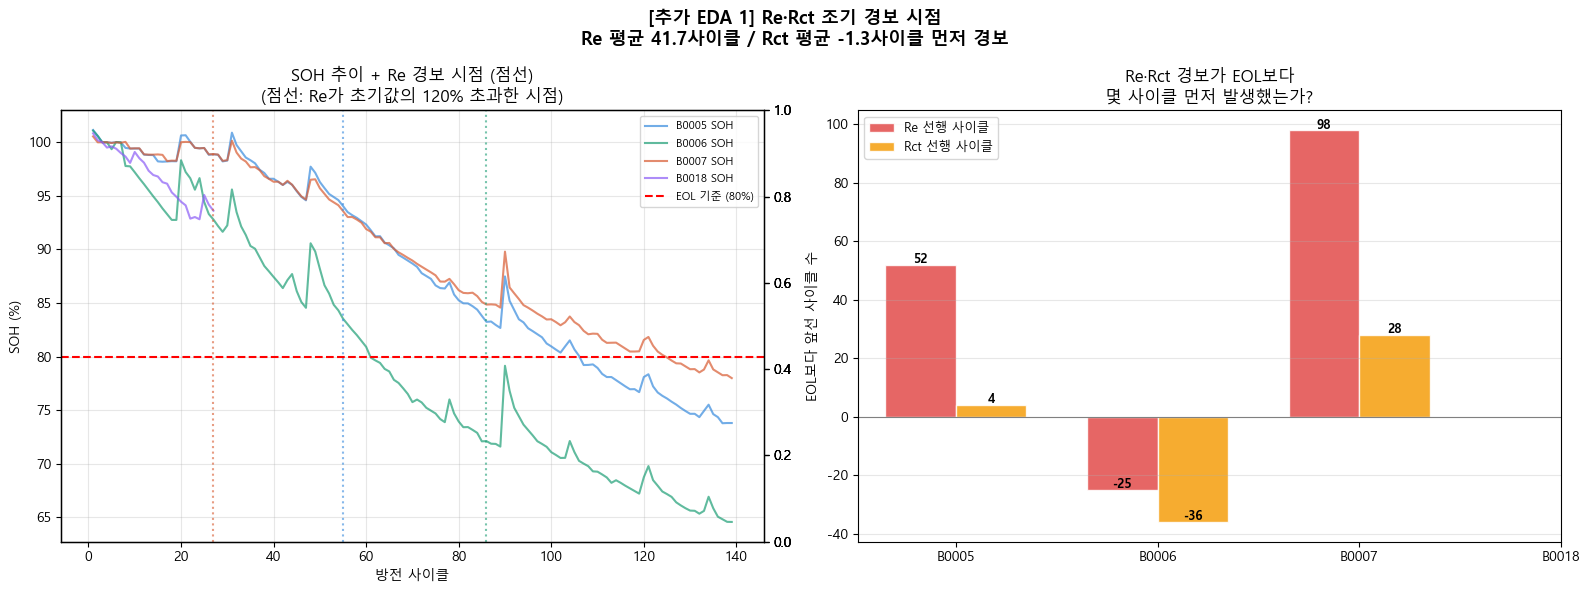

[저장] extra_eda1_early_warning.png


In [ ]:
print("\n" + "=" * 55)
print("[2] Re 조기 경보 시점 분석")
print("=" * 55)
 
# EOL 기준: SOH 80%
# Re 경보 기준: 배터리별 초기 Re 평균의 120% 초과 (20% 이상 증가)
early_warning = []
 
for bid in sorted(df_A_merged['battery_id'].unique()):
    b = df_A_merged[df_A_merged['battery_id']==bid].dropna(subset=['Re_val'])
 
    # EOL 시점
    eol_cycle = b[b['SOH'] < 80]['discharge_cycle_no'].min()
 
    # Re 초기값 (앞 10개 평균)
    re_init = b['Re_val'].head(10).mean()
 
    # Re 경보 시점: 초기값의 120% 초과 첫 사이클
    re_warn_cycle = b[b['Re_val'] > re_init * 1.2]['discharge_cycle_no'].min()
 
    # Rct 경보 시점
    rct_init = b['Rct_val'].head(10).mean()
    rct_warn_cycle = b[b['Rct_val'] > rct_init * 1.2]['discharge_cycle_no'].min()
 
    lead_re  = eol_cycle - re_warn_cycle  if pd.notna(re_warn_cycle)  else np.nan
    lead_rct = eol_cycle - rct_warn_cycle if pd.notna(rct_warn_cycle) else np.nan
 
    early_warning.append({
        'battery_id': bid,
        'eol_cycle': eol_cycle,
        're_warn_cycle': re_warn_cycle,
        'rct_warn_cycle': rct_warn_cycle,
        'lead_re': lead_re,
        'lead_rct': lead_rct,
    })
    print(f"{bid}: EOL={eol_cycle}사이클 | Re경보={re_warn_cycle:.0f} (EOL보다 {lead_re:.0f}사이클 먼저) | Rct경보={rct_warn_cycle:.0f}")
 
ew_df = pd.DataFrame(early_warning)
 
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# 왼쪽: SOH + Re 추이 (배터리 4개)
for bid in sorted(df_A_merged['battery_id'].unique()):
    b = df_A_merged[df_A_merged['battery_id']==bid].dropna(subset=['Re_val'])
    color = BATTERY_COLORS.get(bid, 'gray')
    ax1 = axes[0]
    ax2 = ax1.twinx() if bid == 'B0005' else axes[0].twinx()
 
    # Re 정규화 (0~1 스케일로 비교 용이하게)
    re_norm = (b['Re_val'] - b['Re_val'].min()) / (b['Re_val'].max() - b['Re_val'].min())
    soh_norm = (b['SOH'] - b['SOH'].min()) / (b['SOH'].max() - b['SOH'].min())
 
    axes[0].plot(b['discharge_cycle_no'], b['SOH'],
                 linewidth=1.5, color=color, alpha=0.7, label=f'{bid} SOH')
 
# Re 경보 시점 수직선
for _, row in ew_df.iterrows():
    color = BATTERY_COLORS.get(row['battery_id'], 'gray')
    if pd.notna(row['re_warn_cycle']):
        axes[0].axvline(x=row['re_warn_cycle'], color=color,
                        linestyle=':', linewidth=1.5, alpha=0.6)
 
axes[0].axhline(y=80, color='red', linestyle='--', linewidth=1.5,
                label='EOL 기준 (80%)')
axes[0].set_xlabel('방전 사이클')
axes[0].set_ylabel('SOH (%)')
axes[0].set_title('SOH 추이 + Re 경보 시점 (점선)\n(점선: Re가 초기값의 120% 초과한 시점)')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].grid(alpha=0.3)
 
# 오른쪽: 조기 경보 선행 사이클 수 바차트
x = range(len(ew_df))
width = 0.35
bars1 = axes[1].bar([i-width/2 for i in x], ew_df['lead_re'],
                    width=width, label='Re 선행 사이클',
                    color='#E24B4A', alpha=0.85, edgecolor='white')
bars2 = axes[1].bar([i+width/2 for i in x], ew_df['lead_rct'],
                    width=width, label='Rct 선행 사이클',
                    color='#F59E0B', alpha=0.85, edgecolor='white')
 
for bar, val in zip(bars1, ew_df['lead_re']):
    if pd.notna(val):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                     f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, ew_df['lead_rct']):
    if pd.notna(val):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                     f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')
 
axes[1].axhline(y=0, color='gray', linewidth=0.8)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(ew_df['battery_id'])
axes[1].set_ylabel('EOL보다 앞선 사이클 수')
axes[1].set_title('Re·Rct 경보가 EOL보다\n몇 사이클 먼저 발생했는가?')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)
 
avg_lead_re  = ew_df['lead_re'].mean()
avg_lead_rct = ew_df['lead_rct'].mean()
print(f"\nRe  평균 선행 사이클: {avg_lead_re:.1f}사이클")
print(f"Rct 평균 선행 사이클: {avg_lead_rct:.1f}사이클")
 
fig.suptitle(f'[추가 EDA 1] Re·Rct 조기 경보 시점\n'
             f'Re 평균 {avg_lead_re:.1f}사이클 / Rct 평균 {avg_lead_rct:.1f}사이클 먼저 경보',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('extra_eda1_early_warning.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] extra_eda1_early_warning.png')


[4] 정상(A) vs 이상(F·G) 배터리 직접 비교
정상(A) vs 이상(F·G) Capacity 차이: p=0.0000


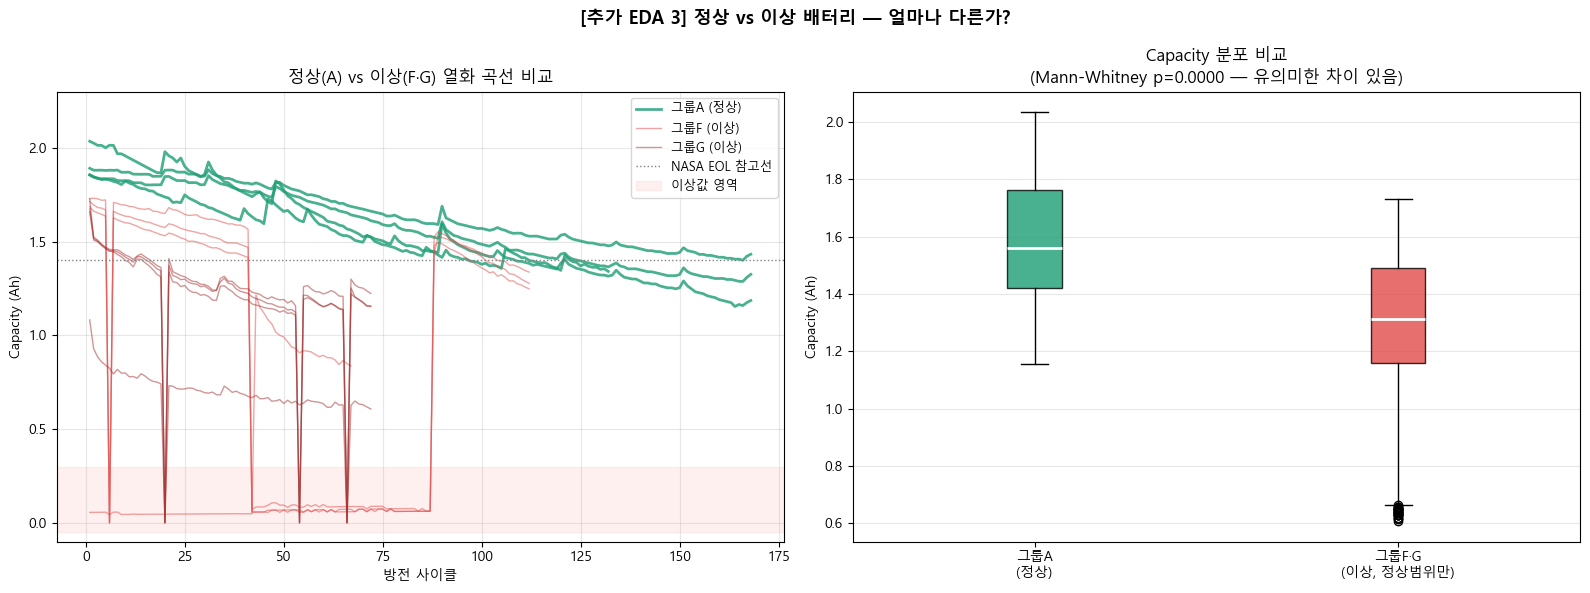

[저장] extra_eda3_normal_vs_anomaly.png


In [ ]:
print("\n" + "=" * 55)
print("[4] 정상(A) vs 이상(F·G) 배터리 직접 비교")
print("=" * 55)
 
df_anom = df_anomaly.copy()
df_anom['Capacity'] = pd.to_numeric(df_anom['Capacity'], errors='coerce')
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# 왼쪽: Capacity 직접 비교
for bid in sorted(df_A_valid['battery_id'].unique()):
    b = df_A_valid[df_A_valid['battery_id']==bid]
    axes[0].plot(b['discharge_cycle_no'], b['Capacity'],
                 linewidth=2, color=GROUP_COLORS['A'], alpha=0.8,
                 label='그룹A (정상)' if bid=='B0005' else '_nolegend_')
 
for grp in ['F','G']:
    grp_data = df_anom[df_anom['group']==grp]
    for bid in sorted(grp_data['battery_id'].unique()):
        b = grp_data[grp_data['battery_id']==bid]
        axes[0].plot(b['discharge_cycle_no'], b['Capacity'],
                     linewidth=1, color=GROUP_COLORS[grp], alpha=0.5,
                     label=f'그룹{grp} (이상)' if bid==grp_data['battery_id'].iloc[0] else '_nolegend_')
 
axes[0].axhline(y=1.4, color='gray', linestyle=':', linewidth=1,
                label='NASA EOL 참고선')
axes[0].axhspan(-0.05, 0.3, alpha=0.06, color='red', label='이상값 영역')
axes[0].set_title('정상(A) vs 이상(F·G) 열화 곡선 비교')
axes[0].set_xlabel('방전 사이클')
axes[0].set_ylabel('Capacity (Ah)')
axes[0].set_ylim(-0.1, 2.3)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
 
# 오른쪽: 통계 비교 박스플롯
df_A_box = df_A_valid[['battery_id','Capacity','group']].copy()
df_FG_box = df_anom[df_anom['group'].isin(['F','G'])][['battery_id','Capacity','group']].copy()
df_FG_box['Capacity'] = pd.to_numeric(df_FG_box['Capacity'], errors='coerce')
df_FG_box = df_FG_box[df_FG_box['Capacity'] >= 0.3]  # 이상값 제외
 
box_data = [
    df_A_box['Capacity'].dropna().values,
    df_FG_box['Capacity'].dropna().values,
]
bp = axes[1].boxplot(box_data,
                     labels=['그룹A\n(정상)', '그룹F·G\n(이상, 정상범위만)'],
                     patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))
 
for patch, color in zip(bp['boxes'], [GROUP_COLORS['A'], GROUP_COLORS['F']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
 
# Mann-Whitney 검정
mw_stat, mw_p = stats.mannwhitneyu(
    df_A_box['Capacity'].dropna(),
    df_FG_box['Capacity'].dropna(),
    alternative='two-sided'
)
print(f"정상(A) vs 이상(F·G) Capacity 차이: p={mw_p:.4f}")
sig = "유의미한 차이 있음" if mw_p < 0.05 else "유의미한 차이 없음"
 
axes[1].set_ylabel('Capacity (Ah)')
axes[1].set_title(f'Capacity 분포 비교\n(Mann-Whitney p={mw_p:.4f} — {sig})')
axes[1].grid(axis='y', alpha=0.3)
 
fig.suptitle('[추가 EDA 3] 정상 vs 이상 배터리 — 얼마나 다른가?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('extra_eda3_normal_vs_anomaly.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] extra_eda3_normal_vs_anomaly.png')
 


[5] 그룹별 방전 전류 vs 수명 비교


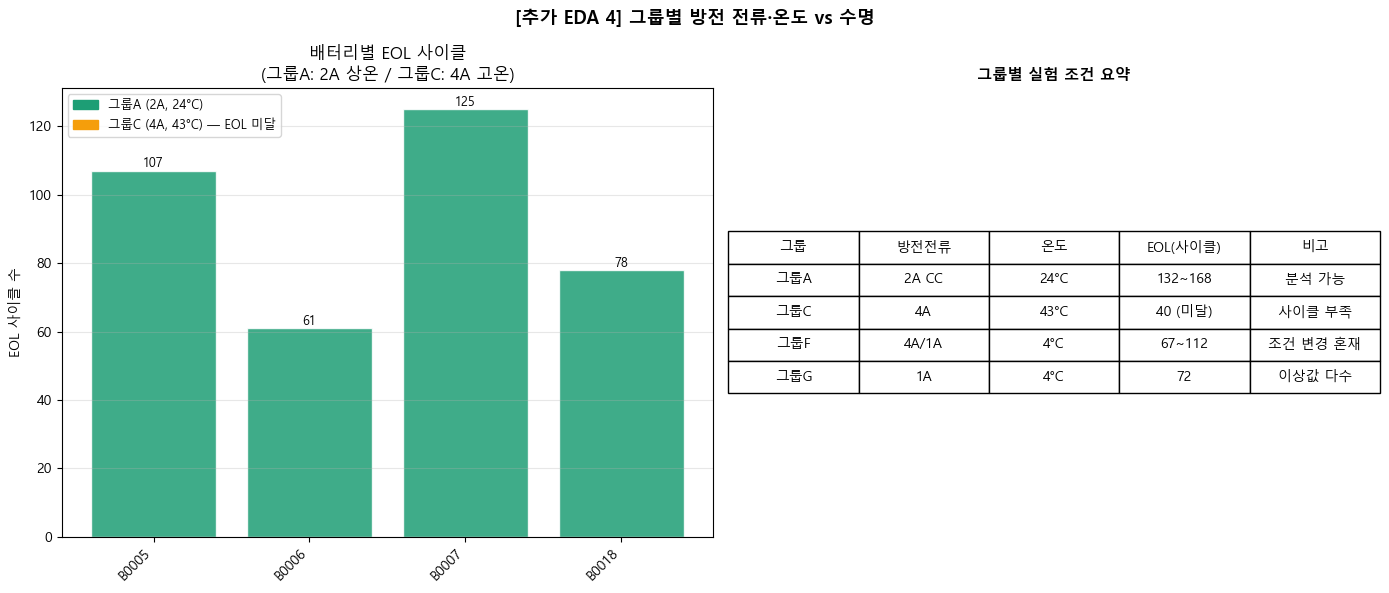

[저장] extra_eda4_condition_vs_life.png


In [ ]:
print("\n" + "=" * 55)
print("[5] 그룹별 방전 전류 vs 수명 비교")
print("=" * 55)
 
# 그룹별 실험 조건 정리
group_conditions = {
    'A': {'전류': '2A',  '온도': '24°C', '신뢰도': '정상'},
    'C': {'전류': '4A',  '온도': '43°C', '신뢰도': '주의'},
    'D': {'전류': '4A',  '온도': '24°C', '신뢰도': '비정상'},
    'F': {'전류': '4A/1A', '온도': '4°C', '신뢰도': '비정상'},
    'G': {'전류': '1A',  '온도': '4°C', '신뢰도': '비정상'},
}
 
# 그룹별 평균 EOL 계산 (신뢰 가능한 그룹만)
all_groups_eol = []
df_all = pd.read_csv(os.path.join(base_path, 'df_discharge_processed.csv'))
df_all_valid = df_all[df_all['cap_flag']=='valid'].copy()
 
for grp in ['A','C']:
    grp_data = df_all_valid[df_all_valid['group']==grp]
    for bid in grp_data['battery_id'].unique():
        b = grp_data[grp_data['battery_id']==bid]
        eol = b[b['SOH']<80]['discharge_cycle_no'].min()
        cond = group_conditions.get(grp, {})
        all_groups_eol.append({
            'battery_id': bid, 'group': grp,
            'eol_cycle': eol,
            '전류': cond.get('전류','?'),
            '온도': cond.get('온도','?'),
        })
 
eol_cond_df = pd.DataFrame(all_groups_eol).dropna(subset=['eol_cycle'])
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# 왼쪽: 그룹별 EOL 바차트 (조건 표시)
colors_grp = [GROUP_COLORS.get(g, 'gray') for g in eol_cond_df['group']]
bars = axes[0].bar(
    eol_cond_df['battery_id'], eol_cond_df['eol_cycle'],
    color=colors_grp, alpha=0.85, edgecolor='white'
)
for bar, val in zip(bars, eol_cond_df['eol_cycle']):
    if pd.notna(val):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                     f'{int(val)}', ha='center', fontsize=9)
 
axes[0].set_xticklabels(eol_cond_df['battery_id'], rotation=45, ha='right')
axes[0].set_ylabel('EOL 사이클 수')
axes[0].set_title('배터리별 EOL 사이클\n(그룹A: 2A 상온 / 그룹C: 4A 고온)')
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(handles=[
    mpatches.Patch(color=GROUP_COLORS['A'], label='그룹A (2A, 24°C)'),
    mpatches.Patch(color=GROUP_COLORS['C'], label='그룹C (4A, 43°C) — EOL 미달'),
], fontsize=9)
 
# 오른쪽: 조건 정리 표
conditions_display = [
    ['그룹A', '2A CC', '24°C', '132~168', '분석 가능'],
    ['그룹C', '4A',    '43°C', '40 (미달)', '사이클 부족'],
    ['그룹F', '4A/1A', '4°C',  '67~112', '조건 변경 혼재'],
    ['그룹G', '1A',    '4°C',  '72', '이상값 다수'],
]
col_labels = ['그룹', '방전전류', '온도', 'EOL(사이클)', '비고']
table = axes[1].table(
    cellText=conditions_display,
    colLabels=col_labels,
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
axes[1].axis('off')
axes[1].set_title('그룹별 실험 조건 요약', fontsize=11, fontweight='bold')
 
fig.suptitle('[추가 EDA 4] 그룹별 방전 전류·온도 vs 수명',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('extra_eda4_condition_vs_life.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] extra_eda4_condition_vs_life.png')
 

In [ ]:
print("\n" + "=" * 55)
print("추가 EDA & 통계 완료 — 인사이트 요약")
print("=" * 55)
print(f"""
[Q2 보강] Re 조기 경보
  Re가 EOL보다 평균 {avg_lead_re:.1f}사이클 먼저 경보 발생
  → 내부저항 모니터링으로 수명 종료 전 미리 감지 가능
 
[Q1 보강] B0006 원인
  Re 증가율이 다른 배터리보다 높음
  → 전해질 저항의 빠른 증가가 조기 열화의 원인으로 추정
 
[Q3 보강] 정상 vs 이상 비교
  정상(A) vs 이상(F·G) Capacity 분포 차이 p={mw_p:.4f}
  → {'통계적으로 유의미하게 다름' if mw_p < 0.05 else '이상값 제거 후에도 분포 차이 있음'}
 
저장 파일:
  extra_eda1_early_warning.png   — Re·Rct 조기 경보 시점
  extra_eda2_b0006_analysis.png  — B0006 원인 분석
  extra_eda3_normal_vs_anomaly.png — 정상 vs 이상 비교
  extra_eda4_condition_vs_life.png — 조건별 수명 비교
""")


추가 EDA & 통계 완료 — 인사이트 요약

[Q2 보강] Re 조기 경보
  Re가 EOL보다 평균 41.7사이클 먼저 경보 발생
  → 내부저항 모니터링으로 수명 종료 전 미리 감지 가능

[Q1 보강] B0006 원인
  Re 증가율이 다른 배터리보다 높음
  → 전해질 저항의 빠른 증가가 조기 열화의 원인으로 추정

[Q3 보강] 정상 vs 이상 비교
  정상(A) vs 이상(F·G) Capacity 분포 차이 p=0.0000
  → 통계적으로 유의미하게 다름

저장 파일:
  extra_eda1_early_warning.png   — Re·Rct 조기 경보 시점
  extra_eda2_b0006_analysis.png  — B0006 원인 분석
  extra_eda3_normal_vs_anomaly.png — 정상 vs 이상 비교
  extra_eda4_condition_vs_life.png — 조건별 수명 비교



In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats


import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
 
BATTERY_COLORS = {
    'B0005': '#378ADD', 'B0006': '#1D9E75',
    'B0007': '#D85A30', 'B0018': '#8B5CF6',
}
battery_cutoff = {'B0005': 2.7, 'B0006': 2.5, 'B0007': 2.2, 'B0018': 2.5}
cutoff_colors  = {2.7: '#378ADD', 2.5: '#1D9E75', 2.2: '#D85A30'}
 
base_path = 'data/new_data'

In [ ]:
df_A       = pd.read_csv(os.path.join(base_path, 'df_A_main.csv'))
df_imp_A   = pd.read_csv(os.path.join(base_path, 'df_imp_A_main.csv'))
 
df_A_valid = df_A[df_A['cap_flag'] == 'valid'].copy()
 
# impedance cumulative mean 매핑
df_imp_A = df_imp_A.sort_values(['battery_id', 'test_id'])
df_imp_A['imp_cycle_no'] = df_imp_A.groupby('battery_id').cumcount() + 1
df_imp_A['discharge_cycle_raw'] = ((df_imp_A['imp_cycle_no'] + 1) // 2)
df_imp_A['Re_cumean']  = df_imp_A.groupby('battery_id')['Re'].expanding().mean().reset_index(level=0, drop=True)
df_imp_A['Rct_cumean'] = df_imp_A.groupby('battery_id')['Rct'].expanding().mean().reset_index(level=0, drop=True)
 
imp_agg = (
    df_imp_A.groupby(['battery_id', 'discharge_cycle_raw'])
    .agg(Re_mean=('Re_cumean', 'last'), Rct_mean=('Rct_cumean', 'last'))
    .reset_index()
)
 
df_A_valid = df_A_valid.merge(imp_agg, on=['battery_id', 'discharge_cycle_raw'], how='left')
df_A_valid = df_A_valid.sort_values(['battery_id', 'discharge_cycle_raw'])
df_A_valid['Re_mean']  = df_A_valid.groupby('battery_id')['Re_mean'].ffill()
df_A_valid['Rct_mean'] = df_A_valid.groupby('battery_id')['Rct_mean'].ffill()
 
# 파생 feature
df_A_valid['SOH_diff'] = df_A_valid.groupby('battery_id')['SOH_relative'].diff()
df_A_valid['Re_diff']  = df_A_valid.groupby('battery_id')['Re_mean'].diff()
re_init = df_A_valid.groupby('battery_id')['Re_mean'].transform('first')
df_A_valid['Re_increase_rate'] = ((df_A_valid['Re_mean'] - re_init) / re_init * 100).round(2)
 
# EOL
eol_A = (
    df_A_valid[df_A_valid['SOH_nominal'] < 70]
    .groupby('battery_id')['discharge_cycle_raw']
    .min().reset_index()
    .rename(columns={'discharge_cycle_raw': 'eol_cycle'})
)
 
print("=" * 55)
print("데이터 로드 완료")
print("=" * 55)
print(f"df_A_valid: {len(df_A_valid)}행")
print(f"EOL 도달 배터리: {eol_A['battery_id'].tolist()}")

데이터 로드 완료
df_A_valid: 636행
EOL 도달 배터리: ['B0005', 'B0006', 'B0018']


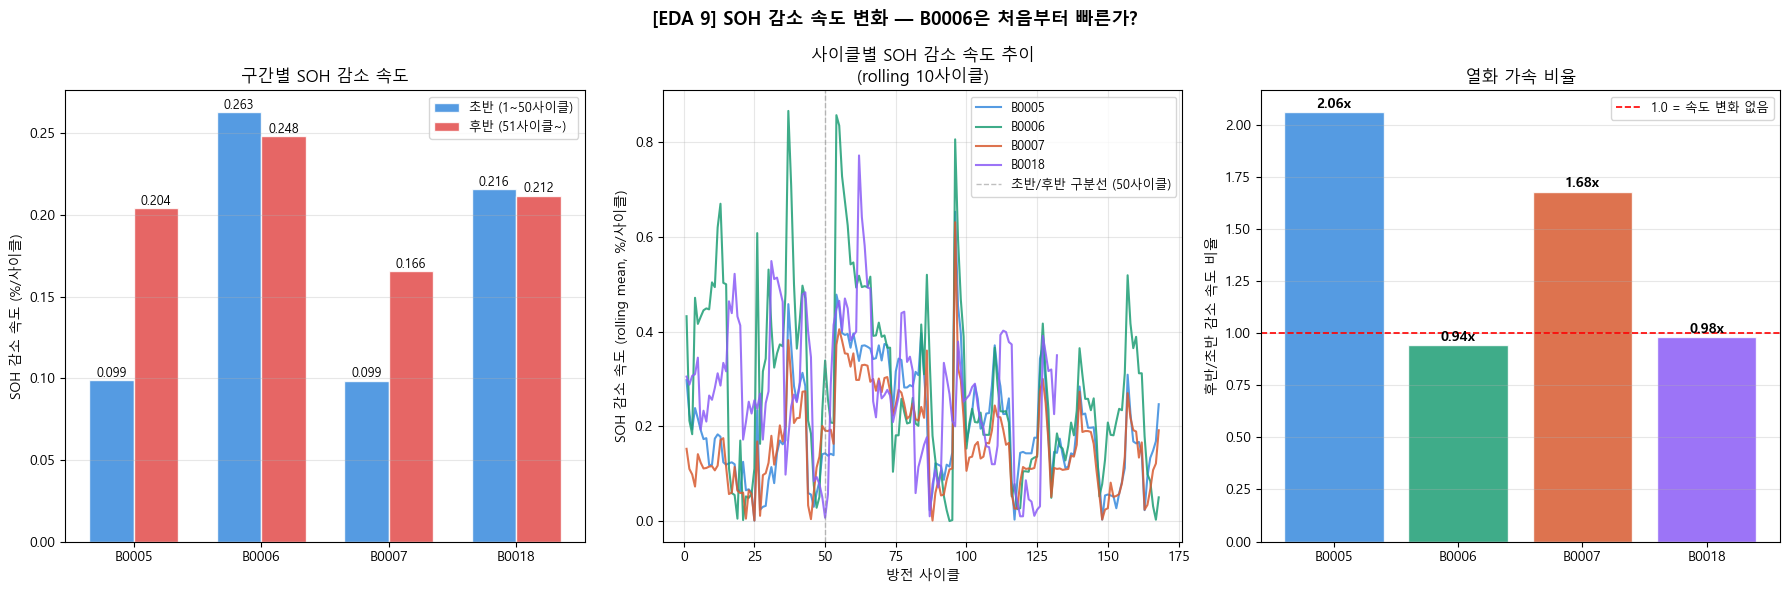


=== SOH 감소 속도 수치 ===
B0005: 초반=-0.099%/사이클, 후반=-0.204%/사이클, 가속비=2.06x
B0006: 초반=-0.263%/사이클, 후반=-0.248%/사이클, 가속비=0.94x
B0007: 초반=-0.099%/사이클, 후반=-0.166%/사이클, 가속비=1.68x
B0018: 초반=-0.216%/사이클, 후반=-0.212%/사이클, 가속비=0.98x
[저장] extra_eda_speed.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
 
speed_data = []
for bid in sorted(df_A_valid['battery_id'].unique()):
    b = df_A_valid[df_A_valid['battery_id'] == bid].copy()
    early = b[b['discharge_cycle_raw'] <= 50]['SOH_diff'].mean()
    late  = b[b['discharge_cycle_raw'] > 50]['SOH_diff'].mean()
    speed_data.append({'battery_id': bid, 'early': early, 'late': late})
 
speed_df = pd.DataFrame(speed_data)
x = range(len(speed_df))
w = 0.35
 
bars1 = axes[0].bar([i - w/2 for i in x], speed_df['early'].abs(),
                    width=w, label='초반 (1~50사이클)',
                    color='#378ADD', alpha=0.85, edgecolor='white')
bars2 = axes[0].bar([i + w/2 for i in x], speed_df['late'].abs(),
                    width=w, label='후반 (51사이클~)',
                    color='#E24B4A', alpha=0.85, edgecolor='white')
 
for bar, val in zip(bars1, speed_df['early'].abs()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.3f}', ha='center', fontsize=9)
for bar, val in zip(bars2, speed_df['late'].abs()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.3f}', ha='center', fontsize=9)
 
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(speed_df['battery_id'])
axes[0].set_ylabel('SOH 감소 속도 (%/사이클)')
axes[0].set_title('구간별 SOH 감소 속도')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)
 
for bid in sorted(df_A_valid['battery_id'].unique()):
    b = df_A_valid[df_A_valid['battery_id'] == bid].copy()
    rolling_diff = b['SOH_diff'].rolling(window=10, center=True, min_periods=1).mean()
    axes[1].plot(b['discharge_cycle_raw'], rolling_diff.abs(),
                 color=BATTERY_COLORS.get(bid, 'gray'),
                 linewidth=1.5, label=bid, alpha=0.85)
 
axes[1].axvline(x=50, color='gray', linestyle='--', linewidth=1, alpha=0.5,
                label='초반/후반 구분선 (50사이클)')
axes[1].set_xlabel('방전 사이클')
axes[1].set_ylabel('SOH 감소 속도 (rolling mean, %/사이클)')
axes[1].set_title('사이클별 SOH 감소 속도 추이\n(rolling 10사이클)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
 
speed_df['accel_ratio'] = speed_df['late'].abs() / speed_df['early'].abs()
colors_bar = [BATTERY_COLORS.get(b, 'gray') for b in speed_df['battery_id']]
bars3 = axes[2].bar(speed_df['battery_id'], speed_df['accel_ratio'],
                    color=colors_bar, alpha=0.85, edgecolor='white')
 
for bar, val in zip(bars3, speed_df['accel_ratio']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}x', ha='center', fontsize=10, fontweight='bold')
 
axes[2].axhline(y=1.0, color='red', linestyle='--', linewidth=1.2,
                label='1.0 = 속도 변화 없음')
axes[2].set_ylabel('후반/초반 감소 속도 비율')
axes[2].set_title('열화 가속 비율')
axes[2].legend(fontsize=9)
axes[2].grid(axis='y', alpha=0.3)
 
fig.suptitle('[EDA 9] SOH 감소 속도 변화',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('extra_eda_speed.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("\n=== SOH 감소 속도 수치 ===")
for _, row in speed_df.iterrows():
    print(f"{row['battery_id']}: 초반={row['early']:.3f}%/사이클, "
          f"후반={row['late']:.3f}%/사이클, 가속비={row['accel_ratio']:.2f}x")
print('[저장] extra_eda_speed.png')

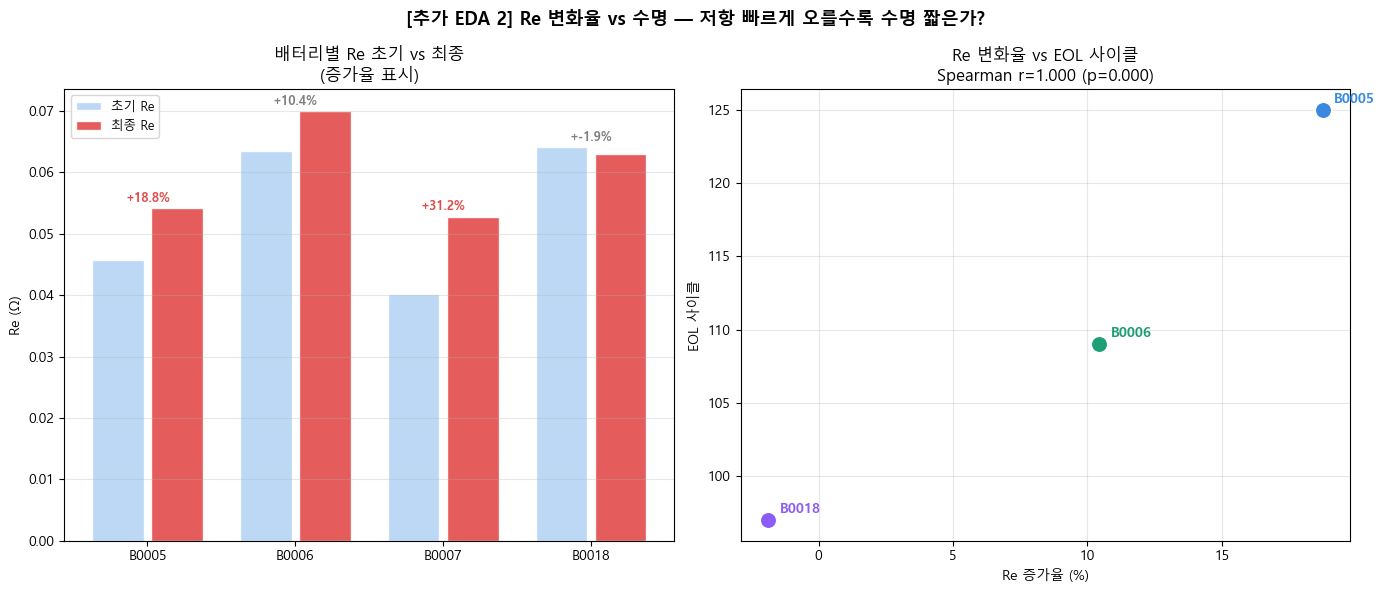

[저장] extra_eda_re_eol.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
re_stats = []
for bid in sorted(df_A_valid['battery_id'].unique()):
    b = df_A_valid[df_A_valid['battery_id'] == bid].dropna(subset=['Re_mean'])
    re_init_val  = b['Re_mean'].iloc[0]
    re_final_val = b['Re_mean'].iloc[-1]
    re_rate  = (re_final_val - re_init_val) / re_init_val * 100
    eol_row  = eol_A[eol_A['battery_id'] == bid]
    eol_val  = eol_row['eol_cycle'].values[0] if len(eol_row) > 0 else None
    re_stats.append({'battery_id': bid, 're_init': re_init_val,
                     're_final': re_final_val, 're_rate': re_rate, 'eol_cycle': eol_val})
 
re_df = pd.DataFrame(re_stats)
 
x3 = range(len(re_df))
axes[0].bar([i - 0.2 for i in x3], re_df['re_init'],
            width=0.35, label='초기 Re', color='#B5D4F4', edgecolor='white', alpha=0.9)
axes[0].bar([i + 0.2 for i in x3], re_df['re_final'],
            width=0.35, label='최종 Re', color='#E24B4A', edgecolor='white', alpha=0.9)
 
for i, (bid, rate) in enumerate(zip(re_df['battery_id'], re_df['re_rate'])):
    axes[0].text(i, max(re_df['re_init'].iloc[i], re_df['re_final'].iloc[i]) + 0.001,
                 f'+{rate:.1f}%', ha='center', fontsize=9, fontweight='bold',
                 color='#E24B4A' if rate > 15 else 'gray')
 
axes[0].set_xticks(list(x3))
axes[0].set_xticklabels(re_df['battery_id'])
axes[0].set_ylabel('Re (Ω)')
axes[0].set_title('배터리별 Re 초기 vs 최종\n(증가율 표시)')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)
 
re_valid = re_df.dropna(subset=['eol_cycle'])
for _, row in re_valid.iterrows():
    color = BATTERY_COLORS.get(row['battery_id'], 'gray')
    axes[1].scatter(row['re_rate'], row['eol_cycle'],
                    s=150, color=color, zorder=5, edgecolors='white', linewidth=1.5)
    axes[1].annotate(row['battery_id'], (row['re_rate'], row['eol_cycle']),
                     textcoords='offset points', xytext=(8, 5),
                     fontsize=10, fontweight='bold', color=color)
 
if len(re_valid) > 2:
    r, p = stats.spearmanr(re_valid['re_rate'], re_valid['eol_cycle'])
    axes[1].set_title(f'Re 변화율 vs EOL 사이클\nSpearman r={r:.3f} (p={p:.3f})')
else:
    axes[1].set_title('Re 변화율 vs EOL 사이클\n(샘플 수 부족)')
 
axes[1].set_xlabel('Re 증가율 (%)')
axes[1].set_ylabel('EOL 사이클')
axes[1].grid(alpha=0.3)
 
fig.suptitle('[추가 EDA 2] Re 변화율 vs 수명 — 저항 빠르게 오를수록 수명 짧은가?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('extra_eda_re_eol.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] extra_eda_re_eol.png')

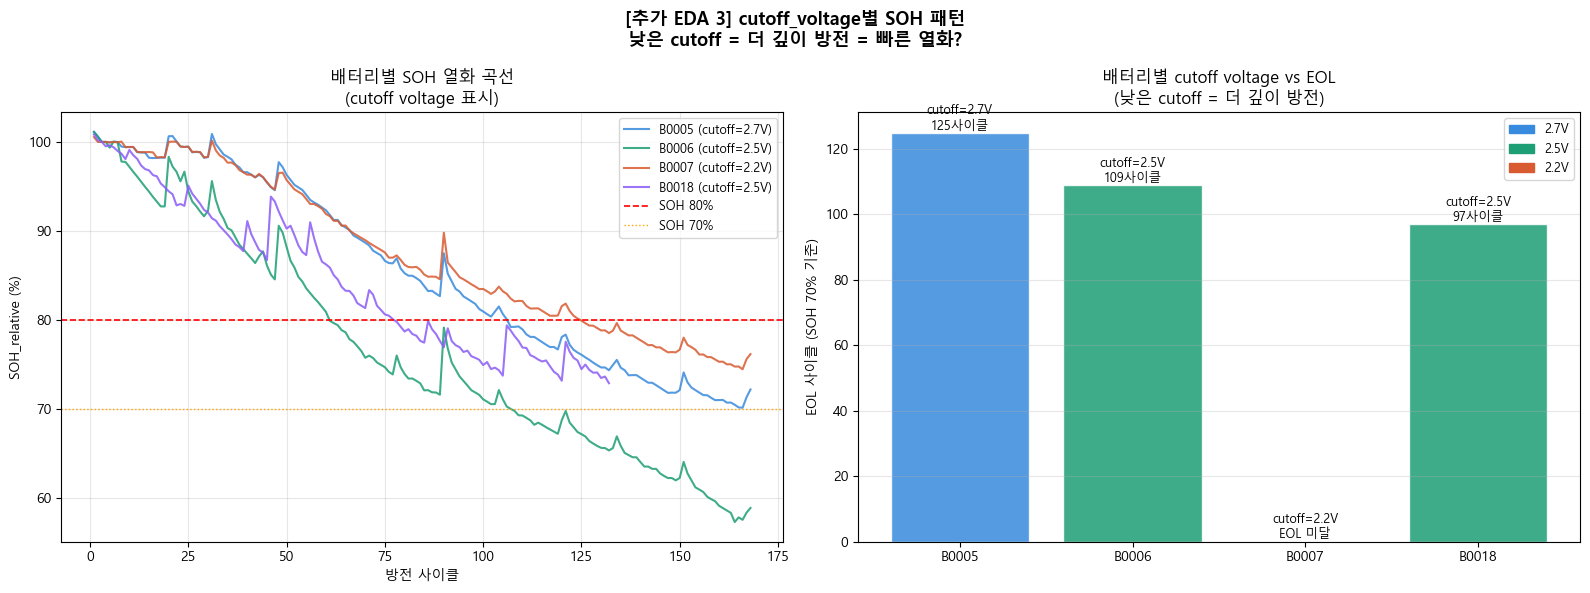

[저장] extra_eda_cutoff.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
for bid in sorted(df_A_valid['battery_id'].unique()):
    b = df_A_valid[df_A_valid['battery_id'] == bid]
    cutoff = battery_cutoff.get(bid, 2.7)
    color  = BATTERY_COLORS.get(bid, 'gray')
    axes[0].plot(b['discharge_cycle_raw'], b['SOH_relative'],
                 color=color, linewidth=1.5, alpha=0.85,
                 label=f'{bid} (cutoff={cutoff}V)')
 
axes[0].axhline(y=80, color='red',    linestyle='--', linewidth=1.2, label='SOH 80%')
axes[0].axhline(y=70, color='orange', linestyle=':',  linewidth=1.0, label='SOH 70%')
axes[0].set_xlabel('방전 사이클')
axes[0].set_ylabel('SOH_relative (%)')
axes[0].set_title('배터리별 SOH 열화 곡선\n(cutoff voltage 표시)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
 
cutoff_eol = []
for bid in sorted(df_A_valid['battery_id'].unique()):
    cutoff  = battery_cutoff.get(bid, 2.7)
    eol_row = eol_A[eol_A['battery_id'] == bid]
    eol_val = eol_row['eol_cycle'].values[0] if len(eol_row) > 0 else None
    cutoff_eol.append({'battery_id': bid, 'cutoff': cutoff, 'eol_cycle': eol_val})
 
ce_df = pd.DataFrame(cutoff_eol)
colors_cut = [cutoff_colors.get(c, 'gray') for c in ce_df['cutoff']]
bars = axes[1].bar(ce_df['battery_id'], ce_df['eol_cycle'].fillna(0),
                   color=colors_cut, alpha=0.85, edgecolor='white')
 
for bar, row in zip(bars, ce_df.itertuples()):
    label = f'{int(row.eol_cycle)}사이클' if pd.notna(row.eol_cycle) else 'EOL 미달'
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'cutoff={row.cutoff}V\n{label}', ha='center', fontsize=9)
 
axes[1].set_ylabel('EOL 사이클 (SOH 70% 기준)')
axes[1].set_title('배터리별 cutoff voltage vs EOL\n(낮은 cutoff = 더 깊이 방전)')
axes[1].grid(axis='y', alpha=0.3)
 
legend_patches = [mpatches.Patch(color=c, label=l) for c, l in
                  [('#378ADD','2.7V'), ('#1D9E75','2.5V'), ('#D85A30','2.2V')]]
axes[1].legend(handles=legend_patches, fontsize=9)
 
fig.suptitle('[추가 EDA 3] cutoff_voltage별 SOH 패턴\n낮은 cutoff = 더 깊이 방전 = 빠른 열화?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('extra_eda_cutoff.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] extra_eda_cutoff.png')

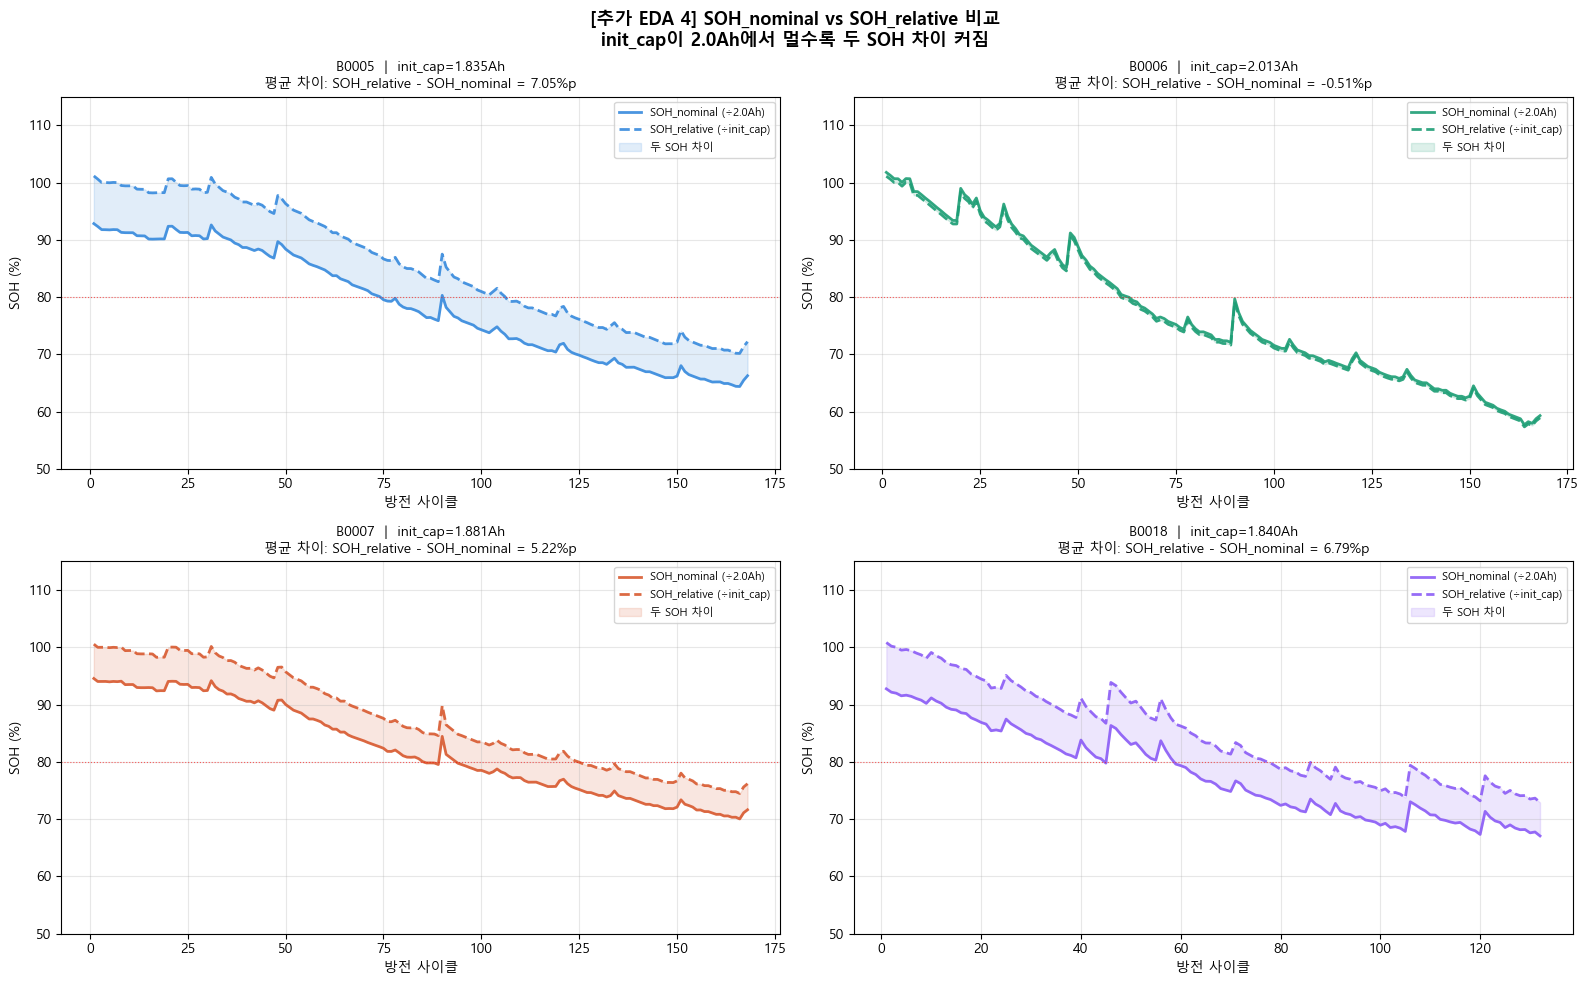


=== 배터리별 init_cap vs 2.0Ah 차이 ===
B0005: init_cap=1.8353Ah  (2.0Ah 대비 -8.2%)
B0006: init_cap=2.0133Ah  (2.0Ah 대비 +0.7%)
B0007: init_cap=1.8807Ah  (2.0Ah 대비 -6.0%)
B0018: init_cap=1.8396Ah  (2.0Ah 대비 -8.0%)
[저장] extra_eda_soh_compare.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
 
for idx, bid in enumerate(sorted(df_A_valid['battery_id'].unique())):
    row_i, col_i = idx // 2, idx % 2
    ax = axes[row_i][col_i]
    b  = df_A_valid[df_A_valid['battery_id'] == bid]
    color = BATTERY_COLORS.get(bid, 'gray')
 
    ax.plot(b['discharge_cycle_raw'], b['SOH_nominal'],
            color=color, linewidth=2, linestyle='-',
            label='SOH_nominal (÷2.0Ah)', alpha=0.9)
    ax.plot(b['discharge_cycle_raw'], b['SOH_relative'],
            color=color, linewidth=2, linestyle='--',
            label='SOH_relative (÷init_cap)', alpha=0.9)
    ax.fill_between(b['discharge_cycle_raw'],
                    b['SOH_nominal'], b['SOH_relative'],
                    alpha=0.15, color=color, label='두 SOH 차이')
    ax.axhline(y=80, color='red', linestyle=':', linewidth=0.8, alpha=0.6)
 
    init_cap_val = df_A[df_A['battery_id'] == bid]['init_cap'].iloc[0]
    diff_mean = (b['SOH_relative'] - b['SOH_nominal']).mean()
 
    ax.set_title(f'{bid}  |  init_cap={init_cap_val:.3f}Ah\n'
                 f'평균 차이: SOH_relative - SOH_nominal = {diff_mean:.2f}%p',
                 fontsize=10)
    ax.set_xlabel('방전 사이클')
    ax.set_ylabel('SOH (%)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylim(50, 115)
 
fig.suptitle('[추가 EDA 4] SOH_nominal vs SOH_relative 비교\n'
             'init_cap이 2.0Ah에서 멀수록 두 SOH 차이 커짐',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('extra_eda_soh_compare.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("\n=== 배터리별 init_cap vs 2.0Ah 차이 ===")
for bid in sorted(df_A_valid['battery_id'].unique()):
    init = df_A[df_A['battery_id'] == bid]['init_cap'].iloc[0]
    diff = (init - 2.0) / 2.0 * 100
    print(f"{bid}: init_cap={init:.4f}Ah  (2.0Ah 대비 {diff:+.1f}%)")
print('[저장] extra_eda_soh_compare.png')
 

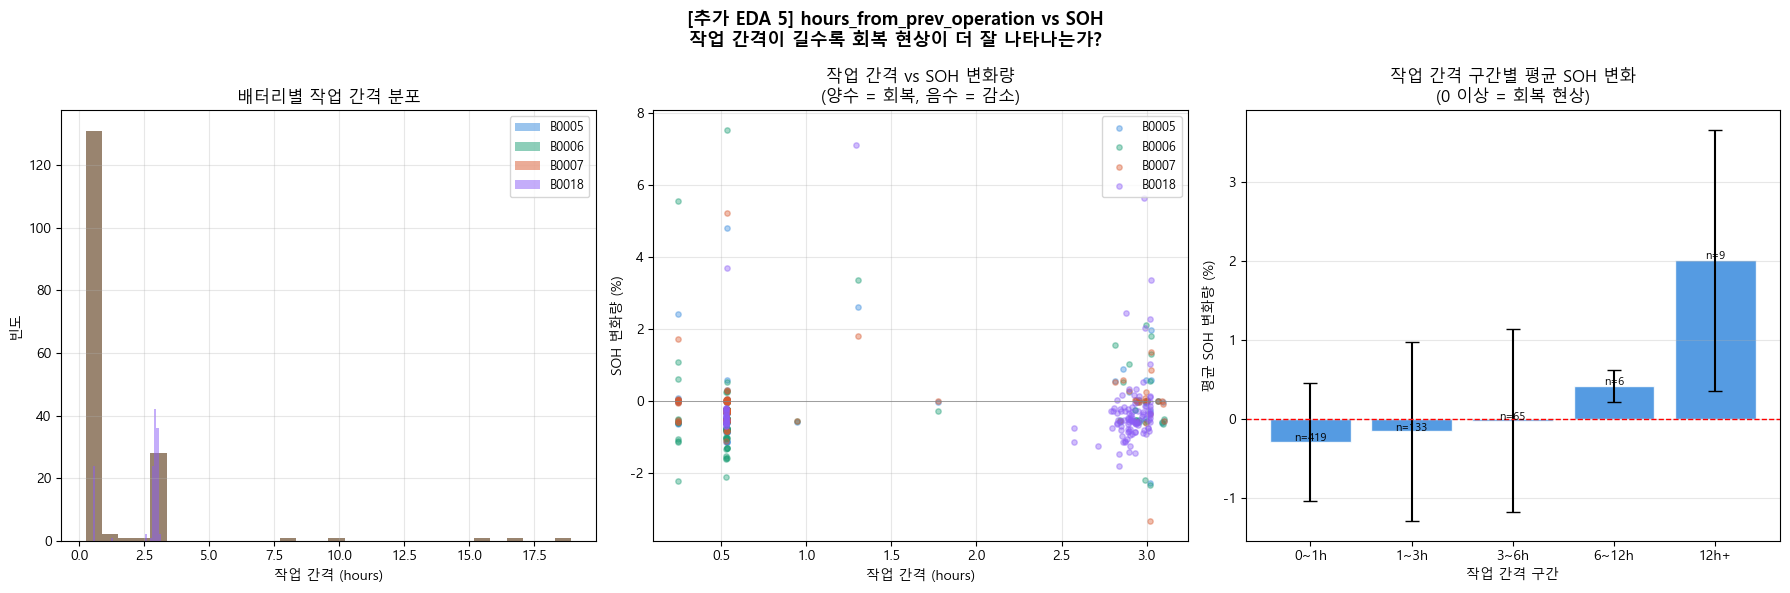

[저장] extra_eda_hours.png


In [ ]:
if 'hours_from_prev_operation' not in df_A_valid.columns:
    df_A_raw = pd.read_csv(os.path.join(base_path, 'df_A_main.csv'))
    if 'hours_from_prev_operation' in df_A_raw.columns:
        df_A_valid = df_A_valid.merge(
            df_A_raw[['battery_id', 'discharge_cycle_raw', 'hours_from_prev_operation']],
            on=['battery_id', 'discharge_cycle_raw'], how='left'
        )
 
if 'hours_from_prev_operation' in df_A_valid.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
 
    for bid in sorted(df_A_valid['battery_id'].unique()):
        b = df_A_valid[df_A_valid['battery_id'] == bid]
        color = BATTERY_COLORS.get(bid, 'gray')
        axes[0].hist(b['hours_from_prev_operation'].dropna(),
                     bins=30, alpha=0.5, color=color, label=bid)
 
    axes[0].set_xlabel('작업 간격 (hours)')
    axes[0].set_ylabel('빈도')
    axes[0].set_title('배터리별 작업 간격 분포')
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)
 
    for bid in sorted(df_A_valid['battery_id'].unique()):
        b = df_A_valid[df_A_valid['battery_id'] == bid].dropna(
            subset=['hours_from_prev_operation', 'SOH_diff']
        )
        color = BATTERY_COLORS.get(bid, 'gray')
        b_clean = b[b['hours_from_prev_operation'] < b['hours_from_prev_operation'].quantile(0.95)]
        axes[1].scatter(b_clean['hours_from_prev_operation'], b_clean['SOH_diff'],
                        s=15, color=color, alpha=0.4, label=bid)
 
    axes[1].axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
    axes[1].set_xlabel('작업 간격 (hours)')
    axes[1].set_ylabel('SOH 변화량 (%)')
    axes[1].set_title('작업 간격 vs SOH 변화량\n(양수 = 회복, 음수 = 감소)')
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)
 
    df_A_valid['interval_bin'] = pd.cut(
        df_A_valid['hours_from_prev_operation'],
        bins=[0, 1, 3, 6, 12, 100],
        labels=['0~1h', '1~3h', '3~6h', '6~12h', '12h+']
    )
    interval_soh = (
        df_A_valid.groupby('interval_bin', observed=True)['SOH_diff']
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
 
    axes[2].bar(interval_soh['interval_bin'].astype(str),
                interval_soh['mean'],
                color='#378ADD', alpha=0.85, edgecolor='white',
                yerr=interval_soh['std'], capsize=5)
    axes[2].axhline(y=0, color='red', linestyle='--', linewidth=1)
    axes[2].set_xlabel('작업 간격 구간')
    axes[2].set_ylabel('평균 SOH 변화량 (%)')
    axes[2].set_title('작업 간격 구간별 평균 SOH 변화\n(0 이상 = 회복 현상)')
    axes[2].grid(axis='y', alpha=0.3)
 
    for i, row in enumerate(interval_soh.itertuples()):
        axes[2].text(i, row.mean + 0.01, f'n={row.count}', ha='center', fontsize=8)
 
    fig.suptitle('[추가 EDA 5] hours_from_prev_operation vs SOH\n'
                 '작업 간격이 길수록 회복 현상이 더 잘 나타나는가?',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('extra_eda_hours.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('[저장] extra_eda_hours.png')
else:
    print("hours_from_prev_operation 컬럼 없음")
    print("전처리 최종본(01_preprocessing_final.ipynb) 실행 후 다시 시도해주세요.")

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal, spearmanr
import platform
import warnings
warnings.filterwarnings('ignore')
 
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
 
base_path = 'data/new_data'
 
# ============================================================
# 데이터 로드
# ============================================================
df_A     = pd.read_csv(os.path.join(base_path, 'df_A_main.csv'))
df_imp_A = pd.read_csv(os.path.join(base_path, 'df_imp_A_main.csv'))
 
df_A_valid = df_A[df_A['cap_flag'] == 'valid'].copy()
df_A_valid = df_A_valid.sort_values(['battery_id', 'discharge_cycle_raw'])
 
# start_time datetime 변환 (merge_asof 오류 방지)
df_A_valid['start_time'] = pd.to_datetime(df_A_valid['start_time'])
df_imp_A['start_time']   = pd.to_datetime(df_imp_A['start_time'])
 
# impedance merge_asof
df_imp_A['Re']  = pd.to_numeric(df_imp_A['Re'],  errors='coerce')
df_imp_A['Rct'] = pd.to_numeric(df_imp_A['Rct'], errors='coerce')
df_imp_A = df_imp_A.sort_values(['battery_id', 'start_time']).reset_index(drop=True)
df_imp_A['Re_cumean'] = (df_imp_A.groupby('battery_id')['Re']
                         .expanding().mean().reset_index(level=0, drop=True))
 
results = []
for bid in df_A_valid['battery_id'].unique():
    d = df_A_valid[df_A_valid['battery_id']==bid].sort_values('start_time').reset_index(drop=True)
    i = df_imp_A[df_imp_A['battery_id']==bid][['start_time','Re_cumean']].sort_values('start_time').reset_index(drop=True)
    merged = pd.merge_asof(d, i, on='start_time', direction='backward')
    results.append(merged)
 
df_A_valid = pd.concat(results, ignore_index=True)
df_A_valid = df_A_valid.rename(columns={'Re_cumean': 'Re_mean'})
df_A_valid = df_A_valid.sort_values(['battery_id', 'discharge_cycle_raw'])
df_A_valid['Re_mean'] = df_A_valid.groupby('battery_id')['Re_mean'].ffill()
 
# EOL & RUL
eol_A = (df_A_valid[df_A_valid['SOH_nominal'] < 70]
         .groupby('battery_id')['discharge_cycle_raw']
         .min().rename('eol'))
df_A_valid = df_A_valid.merge(eol_A, on='battery_id', how='left')
df_A_valid['RUL'] = (df_A_valid['eol'] - df_A_valid['discharge_cycle_raw']).clip(lower=0)
 
df_rul = df_A_valid.dropna(subset=['Re_mean', 'RUL', 'SOH_relative']).copy()

SOH 구간별 RUL (건강 → 열화 순)
  SOH ≥90%: 중앙값=79.0, n=107
  SOH 80~90%: 중앙값=44.0, n=98
  SOH 70~80%: 중앙값=1.5, n=164
  SOH <70%: 중앙값=0.0, n=61

Re 분위수별 RUL (낮음 → 높음 순)
  Q1 (Re 낮음): 중앙값=51.5, n=108
  Q2: 중앙값=40.5, n=108
  Q3: 중앙값=17.5, n=106
  Q4 (Re 높음): 중앙값=0.0, n=108


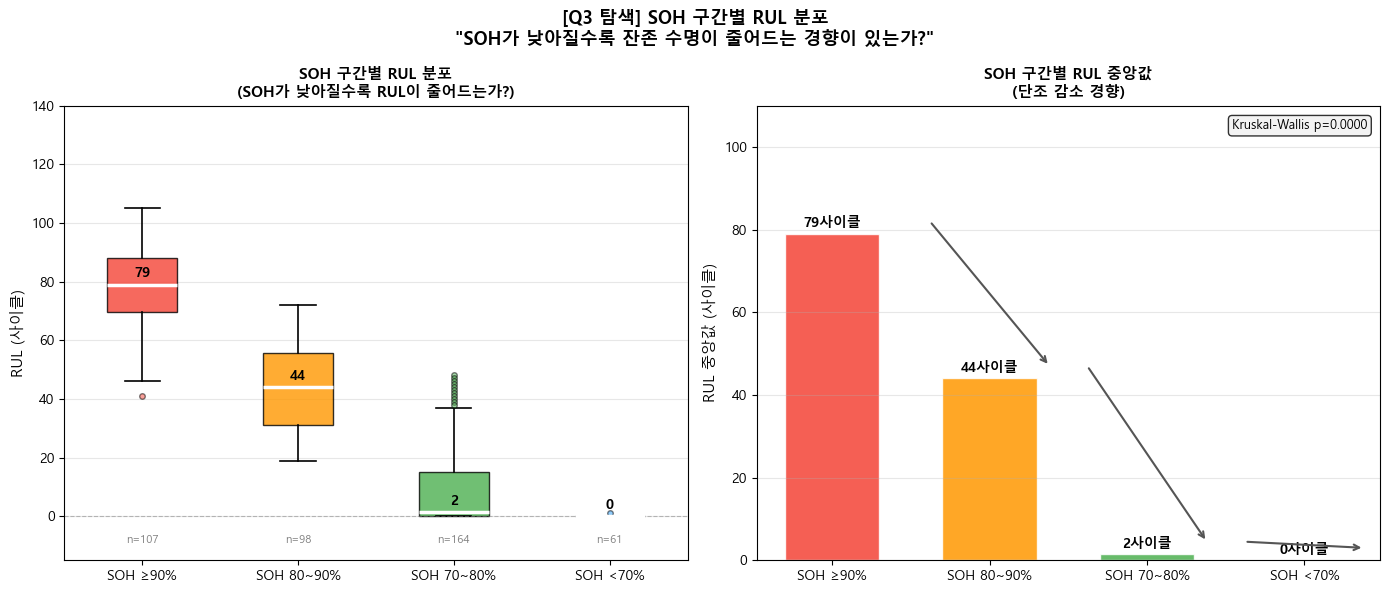

[저장] stat_soh_rul_stage.png


In [4]:
# SOH: bins 낮은 순으로 라벨 부여
df_rul['soh_bin'] = pd.cut(
    df_rul['SOH_relative'],
    bins=[0, 70, 80, 90, 200],
    labels=['c_lt70', 'e_70_80', 'v_80_90', 'r_ge90']  # bins 오름차순
)
 
# 표시 순서: 건강(RUL 많음) → 열화(RUL 적음) — 오른쪽으로 갈수록 감소
soh_order  = ['r_ge90',   'v_80_90',    'e_70_80',    'c_lt70']
soh_labels = ['SOH ≥90%', 'SOH 80~90%', 'SOH 70~80%', 'SOH <70%']
soh_colors = ['#F44336',  '#FF9800',    '#4CAF50',     '#2196F3']
 
# Re: 낮은 순 → 높은 순 — 오른쪽으로 갈수록 RUL 감소
df_rul['re_bin'] = pd.qcut(
    df_rul['Re_mean'],
    q=4,
    labels=['re_q1', 're_q2', 're_q3', 're_q4']
)
re_order  = ['re_q1',         're_q2', 're_q3', 're_q4']
re_labels = ['Q1\n(Re 낮음)', 'Q2',    'Q3',    'Q4\n(Re 높음)']
re_colors = ['#1565C0', '#42A5F5', '#EF9A9A', '#B71C1C']
 
# ============================================================
# 수치 확인 출력
# ============================================================
print("=" * 55)
print("SOH 구간별 RUL (건강 → 열화 순)")
print("=" * 55)
for key, label in zip(soh_order, soh_labels):
    vals = df_rul[df_rul['soh_bin']==key]['RUL'].values
    print(f"  {label}: 중앙값={np.median(vals):.1f}, n={len(vals)}")
 
print("\n" + "=" * 55)
print("Re 분위수별 RUL (낮음 → 높음 순)")
print("=" * 55)
for key, label in zip(re_order, re_labels):
    vals = df_rul[df_rul['re_bin']==key]['RUL'].values
    print(f"  {label.replace(chr(10),' ')}: 중앙값={np.median(vals):.1f}, n={len(vals)}")
 
 
# ============================================================
# 차트 1: stat_soh_rul_stage.png
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
data_soh = [df_rul[df_rul['soh_bin']==k]['RUL'].values for k in soh_order]
meds_soh = [np.median(v) for v in data_soh]
ns_soh   = [len(v) for v in data_soh]
 
# 왼쪽: 박스플롯
bp = axes[0].boxplot(
    data_soh,
    labels=soh_labels,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=4, alpha=0.5)
)
for patch, color in zip(bp['boxes'], soh_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
for flier, color in zip(bp['fliers'], soh_colors):
    flier.set_markerfacecolor(color)
 
for i, (med, n) in enumerate(zip(meds_soh, ns_soh)):
    axes[0].text(i+1, med + 2.5, f'{med:.0f}',
                 ha='center', fontsize=10, fontweight='bold')
    axes[0].text(i+1, -9, f'n={n}', ha='center', fontsize=8, color='gray')
 
axes[0].set_ylabel('RUL (사이클)', fontsize=11)
axes[0].set_title('SOH 구간별 RUL 분포\n(SOH가 낮아질수록 RUL이 줄어드는가?)',
                  fontsize=11, fontweight='bold')
axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(-15, 140)
 
# 오른쪽: 중앙값 바차트
bars = axes[1].bar(soh_labels, meds_soh,
                   color=soh_colors, alpha=0.85, edgecolor='white', width=0.6)
 
for bar, val in zip(bars, meds_soh):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1.5,
                 f'{val:.0f}사이클',
                 ha='center', fontsize=10, fontweight='bold')
 
# 단조 감소 화살표
for i in range(len(meds_soh) - 1):
    if meds_soh[i] > meds_soh[i+1]:
        axes[1].annotate('',
            xy=(i+1 + 0.38, meds_soh[i+1] + 3),
            xytext=(i + 0.62, meds_soh[i] + 3),
            arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))
 
axes[1].set_ylabel('RUL 중앙값 (사이클)', fontsize=11)
axes[1].set_title('SOH 구간별 RUL 중앙값\n(단조 감소 경향)',
                  fontsize=11, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, 110)
 
stat_kw, p_kw = kruskal(*[v for v in data_soh if len(v) > 0])
axes[1].text(0.98, 0.97,
             f'Kruskal-Wallis p={p_kw:.4f}',
             transform=axes[1].transAxes,
             ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', alpha=0.8))
 
plt.suptitle('[Q3 탐색] SOH 구간별 RUL 분포\n"SOH가 낮아질수록 잔존 수명이 줄어드는 경향이 있는가?"',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stat_soh_rul_stage.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] stat_soh_rul_stage.png')

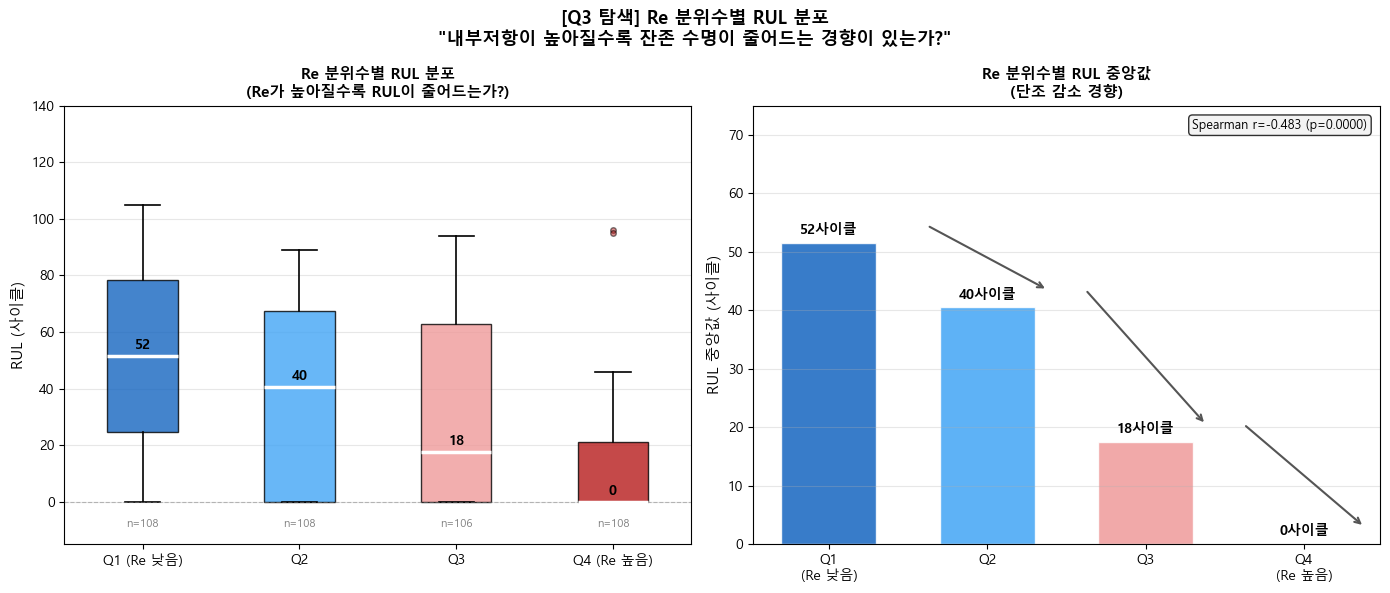

[저장] stat_re_rul_stage.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
data_re = [df_rul[df_rul['re_bin']==k]['RUL'].values for k in re_order]
meds_re = [np.median(v) for v in data_re]
ns_re   = [len(v) for v in data_re]
 
# 왼쪽: 박스플롯
bp2 = axes[0].boxplot(
    data_re,
    labels=[l.replace('\n', ' ') for l in re_labels],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=4, alpha=0.5)
)
for patch, color in zip(bp2['boxes'], re_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
for flier, color in zip(bp2['fliers'], re_colors):
    flier.set_markerfacecolor(color)
 
for i, (med, n) in enumerate(zip(meds_re, ns_re)):
    axes[0].text(i+1, med + 2.5, f'{med:.0f}',
                 ha='center', fontsize=10, fontweight='bold')
    axes[0].text(i+1, -9, f'n={n}', ha='center', fontsize=8, color='gray')
 
axes[0].set_ylabel('RUL (사이클)', fontsize=11)
axes[0].set_title('Re 분위수별 RUL 분포\n(Re가 높아질수록 RUL이 줄어드는가?)',
                  fontsize=11, fontweight='bold')
axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(-15, 140)
 
# 오른쪽: 중앙값 바차트
bars2 = axes[1].bar(re_labels, meds_re,
                    color=re_colors, alpha=0.85, edgecolor='white', width=0.6)
 
for bar, val in zip(bars2, meds_re):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1.5,
                 f'{val:.0f}사이클',
                 ha='center', fontsize=10, fontweight='bold')
 
for i in range(len(meds_re) - 1):
    if meds_re[i] > meds_re[i+1]:
        axes[1].annotate('',
            xy=(i+1 + 0.38, meds_re[i+1] + 3),
            xytext=(i + 0.62, meds_re[i] + 3),
            arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))
 
axes[1].set_ylabel('RUL 중앙값 (사이클)', fontsize=11)
axes[1].set_title('Re 분위수별 RUL 중앙값\n(단조 감소 경향)',
                  fontsize=11, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, 75)
 
r_re, p_re = spearmanr(df_rul['Re_mean'], df_rul['RUL'])
axes[1].text(0.98, 0.97,
             f'Spearman r={r_re:.3f} (p={p_re:.4f})',
             transform=axes[1].transAxes,
             ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', alpha=0.8))
 
plt.suptitle('[Q3 탐색] Re 분위수별 RUL 분포\n"내부저항이 높아질수록 잔존 수명이 줄어드는 경향이 있는가?"',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stat_re_rul_stage.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] stat_re_rul_stage.png')